# Identificação do Aeropêndulo com Neural ODEs
Comparação entre um Modelo Fisicamente Informado (Physics-Informed) e um Modelo Caixa-Preta (Black-Box).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchdiffeq import odeint
from scipy.signal import savgol_filter

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


[notice] A new release of pip is available: 24.3.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Using device: cuda


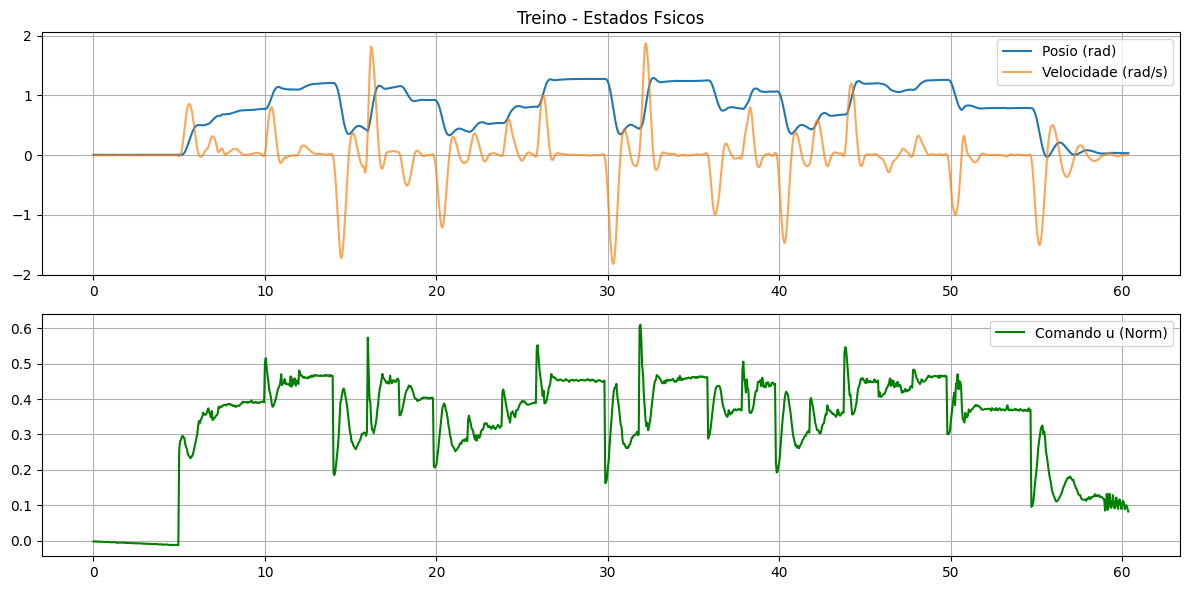

In [2]:
def carregar_experimento(url, decimacao=1):
    df = pd.read_csv(url)
    df_sub = df.iloc[::decimacao].copy().reset_index(drop=True)
    
    if 'u_pct' in df_sub.columns:
        u_raw = df_sub['u_pct'].values
    else:
        u_raw = df_sub['motor_percent'].values
        
    y_raw = df_sub['angulo_deg'].values
    
    # Ignoramos a coluna tempo_ms pois ela contém saltos anômalos que quebram o odeint no PyTorch (float32).
    # Como a amostragem é constante, geramos um vetor de tempo sintético estritamente crescente.
    dt = 0.010 * decimacao  # aprox 10ms por amostra no original
    t_raw = np.arange(len(y_raw)) * dt
        
    return t_raw, u_raw, y_raw

BASE2 = (
    "https://raw.githubusercontent.com/FelipeEduardoMarcondes/"
    "SYSTEM-IDENTIFICATION-AERO/main/experimentos/"
)

# Carregando dados
decimacao = 5 # Decimao para deixar a dinmica evidente para as ODES
t_train, u_train_raw, y_train_deg = carregar_experimento(BASE2 + "multi-sine-2_0731_17-38.csv", decimacao=decimacao)
t_test, u_test_raw, y_test_deg = carregar_experimento(BASE2 + "multi-sine-3_0731_17-45.csv", decimacao=decimacao)

# Forar o tempo inicial para zero
t_train = t_train - t_train[0]
t_test = t_test - t_test[0]

# --- PROCESSAMENTO DOS ESTADOS (CONVERSO FSICA) ---
# A Equao Diferencial opera no mundo real (radianos)
y_train_rad = y_train_deg * (np.pi / 180.0)
y_test_rad = y_test_deg * (np.pi / 180.0)

# Normalizao de entrada u (0 a 100% -> 0 a 1)
u_train = u_train_raw / 100.0
u_test = u_test_raw / 100.0

# --- CLCULO DA VELOCIDADE ANGULAR ---
# Usaremos um filtro de Savitzky-Golay para derivar e suavizar a posio simultaneamente
dt_train = np.mean(np.diff(t_train))
dt_test = np.mean(np.diff(t_test))

window = 11
poly = 3
v_train_rad_s = savgol_filter(y_train_rad, window, poly, deriv=1, delta=dt_train)
v_test_rad_s = savgol_filter(y_test_rad, window, poly, deriv=1, delta=dt_test)

# Montando a matriz de estados x = [posio, velocidade]
x_train = np.vstack((y_train_rad, v_train_rad_s)).T
x_test = np.vstack((y_test_rad, v_test_rad_s)).T

# Convertendo tudo para Tensores do PyTorch
t_tensor_train = torch.tensor(t_train, dtype=torch.float32)
u_tensor_train = torch.tensor(u_train, dtype=torch.float32).unsqueeze(1)
x_tensor_train = torch.tensor(x_train, dtype=torch.float32)

t_tensor_test = torch.tensor(t_test, dtype=torch.float32)
u_tensor_test = torch.tensor(u_test, dtype=torch.float32).unsqueeze(1)
x_tensor_test = torch.tensor(x_test, dtype=torch.float32)

plt.figure(figsize=(12, 6))
plt.subplot(2,1,1)
plt.plot(t_train, y_train_rad, label='Posio (rad)')
plt.plot(t_train, v_train_rad_s, label='Velocidade (rad/s)', alpha=0.7)
plt.title('Treino - Estados Fsicos')
plt.grid(); plt.legend()

plt.subplot(2,1,2)
plt.plot(t_train, u_train, label='Comando u (Norm)', color='green')
plt.grid(); plt.legend()
plt.tight_layout(); plt.show()

In [ ]:
# ==========================================
# 1. MODELOS ODE (NODE)
# ==========================================
class PhysicsODE(nn.Module):
    def __init__(self):
        super().__init__()
        
        # --- VALORES FÍSICOS CONHECIDOS DA BANCADA ---
        self.m1 = 1.0  # Massa do lado da hélice (kg)
        self.L1 = 1.0  # Distância do pivô até a hélice (m)
        self.m2 = 1.0  # Massa do contrapeso (kg)
        self.L2 = 1.0  # Distância do pivô até o contrapeso (m)
        self.g = 9.81  # Gravidade (m/s^2)
        
        # Parâmetros Desconhecidos que a Rede Neural vai descobrir:
        # Inércia (J), Atrito (b), Ganho do Motor (Gu)
        self.log_J = nn.Parameter(torch.tensor(0.0))
        self.log_b = nn.Parameter(torch.tensor(-1.0))
        self.log_Gu = nn.Parameter(torch.tensor(0.0))
        
        self.u_series = None
        self.t_series = None
        self.batch_start_times = None

    def get_params(self):
        return torch.exp(self.log_J), torch.exp(self.log_b), torch.exp(self.log_Gu)

    def forward(self, t, x):
        J, b, Gu = self.get_params()
        
        # Equacionamento dinâmico
        p1 = b / J
        p2 = ((self.m1 * self.L1 - self.m2 * self.L2) * self.g) / J
        p3 = Gu / J

        # Alinhamento temporal para mini-batches
        if self.batch_start_times is not None:
            t_abs = self.batch_start_times + t
        else:
            t_abs = t * torch.ones_like(x[:, 0:1])

        # Interpolao do sinal de controle u(t)
        k = torch.searchsorted(self.t_series, t_abs.reshape(-1), right=True)
        k = torch.clamp(k, 1, len(self.t_series) - 1)
        
        t1, t2 = self.t_series[k-1].unsqueeze(1), self.t_series[k].unsqueeze(1)
        u1, u2 = self.u_series[k-1], self.u_series[k]

        denom = (t2 - t1)
        denom[denom < 1e-6] = 1.0
        alpha = (t_abs - t1) / denom
        u_t = u1 + alpha * (u2 - u1)

        # Estados: posio (theta) e velocidade (theta_dot)
        theta, theta_dot = x[:, 0:1], x[:, 1:2]
        
        # theta_ddot = - (b/J)*theta_dot - ((m1L1-m2L2)g/J)*sin(theta) + u_gain * (u^2)
        theta_ddot = - p1 * theta_dot - p2 * torch.sin(theta) + p3 * (u_t ** 2)
        
        return torch.cat([theta_dot, theta_ddot], dim=1)


class BlackBoxODE(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden_dim), # [theta, theta_dot, u]
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 2)  # [theta_dot, theta_ddot]
        )
        self.u_series = None
        self.t_series = None
        self.batch_start_times = None

    def forward(self, t, x):
        if self.batch_start_times is not None:
            t_abs = self.batch_start_times + t
        else:
            t_abs = t * torch.ones_like(x[:, 0:1])

        k = torch.searchsorted(self.t_series, t_abs.reshape(-1), right=True)
        k = torch.clamp(k, 1, len(self.t_series) - 1)

        t1, t2 = self.t_series[k-1].unsqueeze(1), self.t_series[k].unsqueeze(1)
        u1, u2 = self.u_series[k-1], self.u_series[k]

        denom = (t2 - t1)
        denom[denom < 1e-6] = 1.0
        alpha = (t_abs - t1) / denom
        u_t = u1 + alpha * (u2 - u1)

        nn_input = torch.cat([x, u_t], dim=1)
        return self.net(nn_input)

In [4]:
# ==========================================
# 2. FUNO DE TREINAMENTO (MINI-BATCHES)
# ==========================================
def train_model(model, name, epochs=300, lr=0.01, k_steps=20):
    print(f"--- Iniciando Treinamento: {name} ---")
    model.to(device)
    model.u_series = u_tensor_train.to(device)
    model.t_series = t_tensor_train.to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    BATCH_SIZE = 128
    dt = (t_tensor_train[1] - t_tensor_train[0]).item()
    t_eval = torch.arange(0, k_steps * dt, dt, device=device)

    y_t = x_tensor_train.to(device) # Alvo so os dois estados!
    
    for epoch in range(epochs + 1):
        optimizer.zero_grad()

        # Seleciona pontos de partida aleatrios no tempo
        start_idx = np.random.randint(0, len(t_tensor_train) - k_steps, size=BATCH_SIZE)
        x0 = y_t[start_idx]
        model.batch_start_times = t_tensor_train[start_idx].reshape(-1, 1).to(device)

        # Roda a integrao de curto prazo (Rollout k-steps)
        pred_state = odeint(model, x0, t_eval, method='rk4')

        # Compara com o alvo
        batch_targets = []
        for i in start_idx:
            batch_targets.append(y_t[i:i+k_steps])
        y_target = torch.stack(batch_targets, dim=1)

        loss = torch.mean((pred_state - y_target)**2)
        loss.backward()
        optimizer.step()

        if epoch % 100 == 0:
            print(f"Epoch {epoch:4d} | Loss: {loss.item():.6f}")

    return model

In [5]:
# Treinando o modelo Físico
phys_model = PhysicsODE()
phys_model = train_model(phys_model, "Physics-Informed Model (Caixa-Cinza)", epochs=500, lr=0.02, k_steps=20)

J, b, Gu = phys_model.get_params()
p2 = ((phys_model.m1 * phys_model.L1 - phys_model.m2 * phys_model.L2) * phys_model.g) / J

print("\nParâmetros Físicos Encontrados (e calculados):")
print(f"J (Inércia descoberta): {J.item():.4f} kg.m^2")
print(f"b (Atrito descoberto): {b.item():.4f}")
print(f"Gu (Ganho Motor descoberto): {Gu.item():.4f}\n")

# Treinando o modelo Caixa-Preta (MLP)
bb_model = BlackBoxODE(hidden_dim=32)
bb_model = train_model(bb_model, "Black-Box Model (MLP)", epochs=500, lr=0.01, k_steps=20)

SyntaxError: unterminated string literal (detected at line 7) (3701400690.py, line 7)

In [ ]:
# ==========================================
# 3. VALIDAO FREE-RUN (SIMULAO COMPLETA)
# ==========================================
print("\n--- Simulao Free-Run no Conjunto de TESTE ---")

with torch.no_grad():
    # Passando os dados de teste para o modelo saber usar a entrada certa
    phys_model.u_series = u_tensor_test.to(device)
    phys_model.t_series = t_tensor_test.to(device)
    phys_model.batch_start_times = torch.zeros(1, 1).to(device)
    
    bb_model.u_series = u_tensor_test.to(device)
    bb_model.t_series = t_tensor_test.to(device)
    bb_model.batch_start_times = torch.zeros(1, 1).to(device)

    # Condio inicial do teste (posio e velocidade na amostra 0)
    x0_test = x_tensor_test[0].unsqueeze(0).to(device) # Shape (1, 2)

    # Simulao Pura (rk4 do comeo ao fim)
    full_pred_phys = odeint(phys_model, x0_test, t_tensor_test.to(device), method='rk4')
    full_pred_phys = full_pred_phys.squeeze(1).cpu().numpy()

    full_pred_bb = odeint(bb_model, x0_test, t_tensor_test.to(device), method='rk4')
    full_pred_bb = full_pred_bb.squeeze(1).cpu().numpy()

# Convertendo radianos de volta para Graus para a plotagem
y_test_deg_real = x_test[:, 0] * (180.0 / np.pi)
phys_deg_pred = full_pred_phys[:, 0] * (180.0 / np.pi)
bb_deg_pred = full_pred_bb[:, 0] * (180.0 / np.pi)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(t_test, y_test_deg_real, 'k-', linewidth=2, label='Real (Teste)')
plt.plot(t_test, phys_deg_pred, 'r--', linewidth=2, label='Physics-Informed')
plt.title("Validao Free-Run: Posio (ngulo)")
plt.ylabel("ngulo (graus)")
plt.xlabel("Tempo (s)")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(t_test, y_test_deg_real, 'k-', linewidth=2, label='Real (Teste)')
plt.plot(t_test, bb_deg_pred, 'b--', linewidth=2, label='Black-Box')
plt.title("Validao Free-Run: Posio (ngulo)")
plt.ylabel("ngulo (graus)")
plt.xlabel("Tempo (s)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()